<a href="https://colab.research.google.com/github/Vrinda-2004/Assessmenttest/blob/main/SupervisedLearningCASE_STUDY.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [196]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV

from sklearn.preprocessing import LabelEncoder, StandardScaler

from sklearn.impute import SimpleImputer

from sklearn.metrics import (accuracy_score,
                             precision_score,
                             recall_score,
                             f1_score,
                             roc_auc_score,
                             confusion_matrix,
                             classification_report)

from sklearn.linear_model import LogisticRegression

from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier

In [197]:
train = pd.read_csv("Training_data.csv")

train.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,9509-MPYOD,Female,0,No,No,35,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,One year,No,Mailed check,20.75,700.45,No
1,7746-AWNQW,Female,0,No,No,28,No,No phone service,DSL,No,...,Yes,Yes,No,No,Month-to-month,Yes,Mailed check,35.75,961.4,No
2,2208-UGTGR,Male,0,No,No,56,Yes,Yes,Fiber optic,No,...,No,No,Yes,Yes,Month-to-month,No,Electronic check,98.60,5581.05,No
3,4884-LEVMQ,Male,0,Yes,No,39,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,Yes,Bank transfer (automatic),20.45,790,No
4,6682-VCIXC,Female,0,Yes,Yes,43,No,No phone service,DSL,NaN,...,No,Yes,Yes,No,One year,Yes,Bank transfer (automatic),51.25,2151.6,No


In [198]:
train.shape

(5634, 21)

In [199]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5634 entries, 0 to 5633
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        5634 non-null   object 
 1   gender            5465 non-null   object 
 2   SeniorCitizen     5634 non-null   int64  
 3   Partner           5634 non-null   object 
 4   Dependents        5634 non-null   object 
 5   tenure            5634 non-null   int64  
 6   PhoneService      5634 non-null   object 
 7   MultipleLines     5634 non-null   object 
 8   InternetService   5634 non-null   object 
 9   OnlineSecurity    5465 non-null   object 
 10  OnlineBackup      5634 non-null   object 
 11  DeviceProtection  5634 non-null   object 
 12  TechSupport       5634 non-null   object 
 13  StreamingTV       5634 non-null   object 
 14  StreamingMovies   5634 non-null   object 
 15  Contract          5634 non-null   object 
 16  PaperlessBilling  5634 non-null   object 


In [200]:
train.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,5634.000000,5634.000000,5240.000000
mean,0.159744,32.606851,65.102052
std,0.366401,24.614976,30.056443
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,36.800000
50%,0.000000,29.000000,70.650000
75%,0.000000,56.000000,90.050000
max,1.000000,72.000000,118.750000


In [201]:
train.isnull().sum()

,0
customerID,0
gender,169
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,169


In [202]:
# Also check blank values in TotalCharges
(train['TotalCharges']==" ").sum()

np.int64(9)

In [203]:
# Replace blanks with NaN
train['TotalCharges']=train['TotalCharges'].replace(" ",np.nan)

train['TotalCharges']=train['TotalCharges'].astype(float)

In [204]:
# Again check missing values
train.isnull().sum()

,0
customerID,0
gender,169
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,169


In [205]:
# Handle Missing Values
imputer=SimpleImputer(strategy="median")

train['TotalCharges']=imputer.fit_transform(train[['TotalCharges']])

In [206]:
# Duplicate Values
train.duplicated().sum()

np.int64(0)

In [207]:
# Remove duplicates
train=train.drop_duplicates()

In [208]:
train=train.drop("customerID",axis=1)

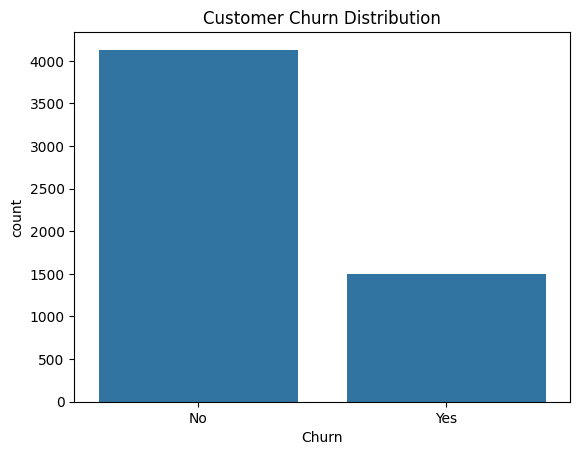

In [209]:
# Target Variable Distribution
sns.countplot(x='Churn',data=train)

plt.title("Customer Churn Distribution")

plt.show()

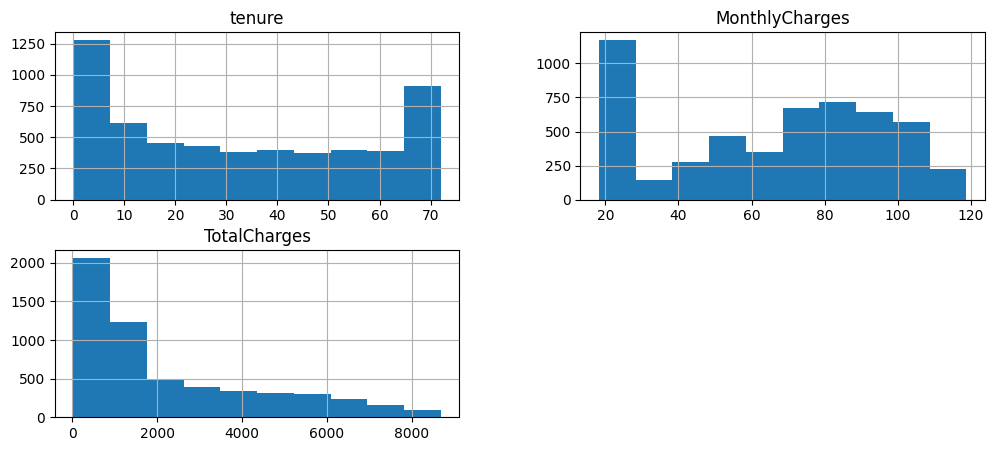

In [210]:
# Numerical Features Distribution
num_cols=['tenure','MonthlyCharges','TotalCharges']

train[num_cols].hist(figsize=(12,5))

plt.show()

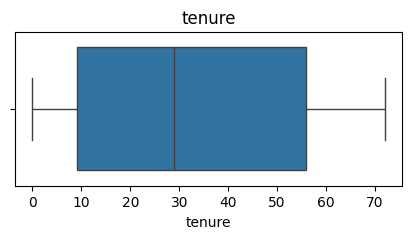

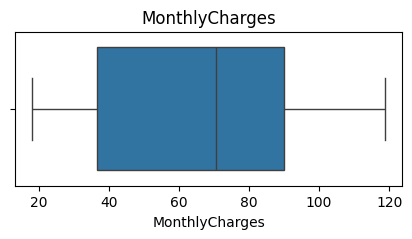

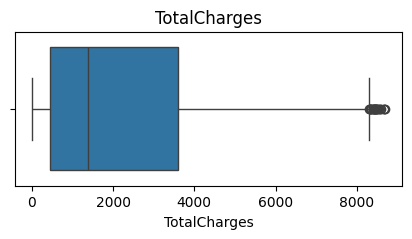

In [211]:
for col in num_cols:
    plt.figure(figsize=(5,2))
    sns.boxplot(x=train[col])
    plt.title(col)
    plt.show()

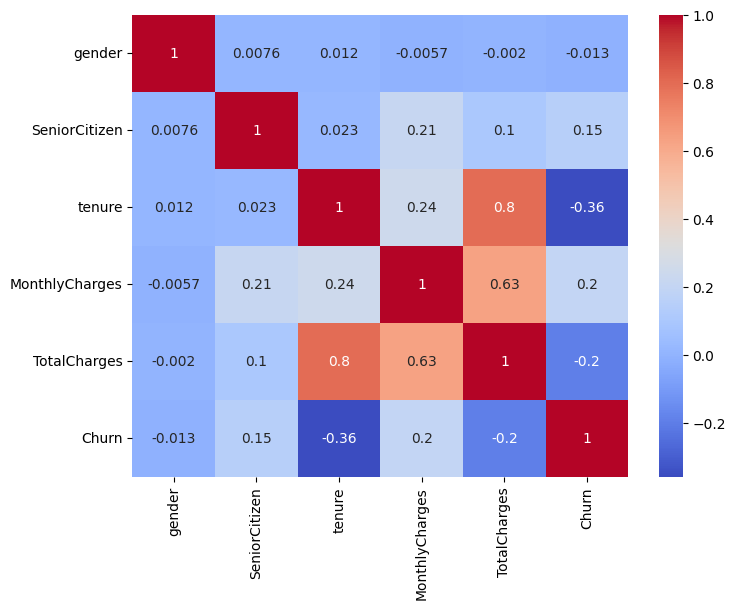

In [212]:
# Correlation Heatmap
# Encode target temporarily

temp=train.copy()
temp['Churn']=temp['Churn'].map({'Yes':1,'No':0})
temp['gender']=temp['gender'].map({'Male':1,'Female':0})
corr=temp.corr(numeric_only=True)
plt.figure(figsize=(8,6))
sns.heatmap(corr,annot=True,cmap='coolwarm')
plt.show()

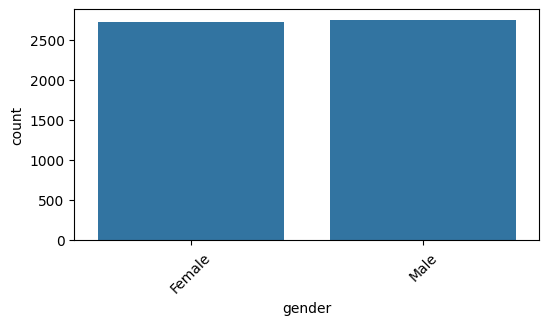

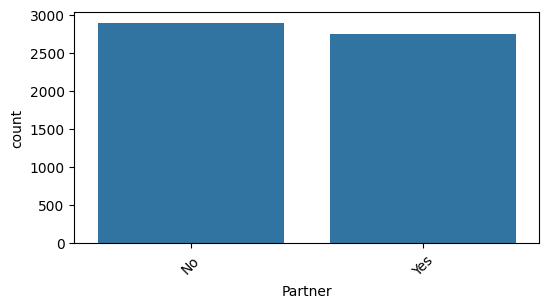

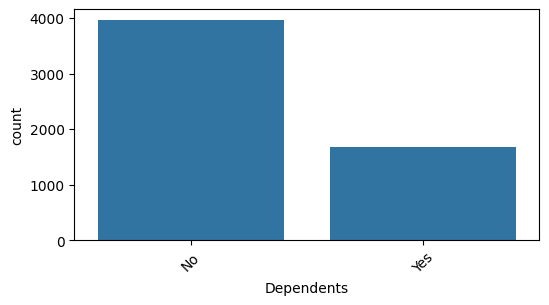

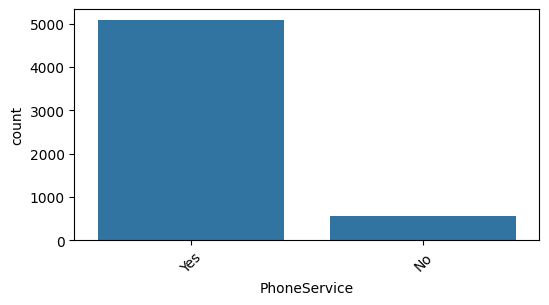

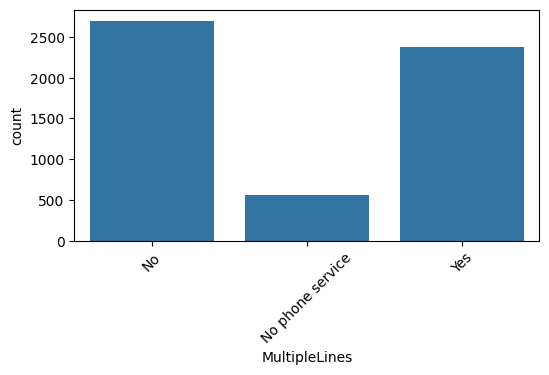

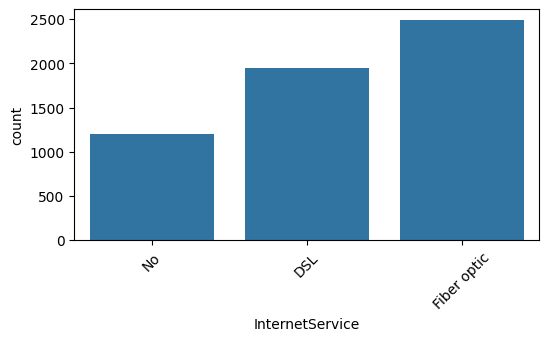

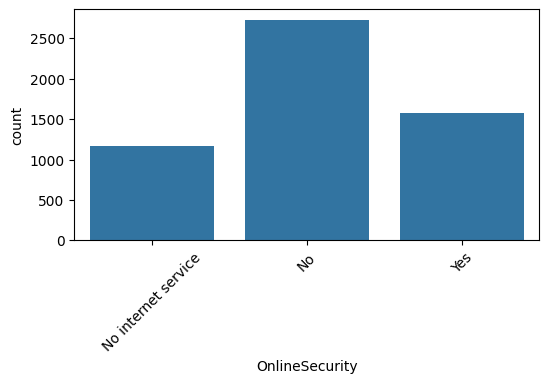

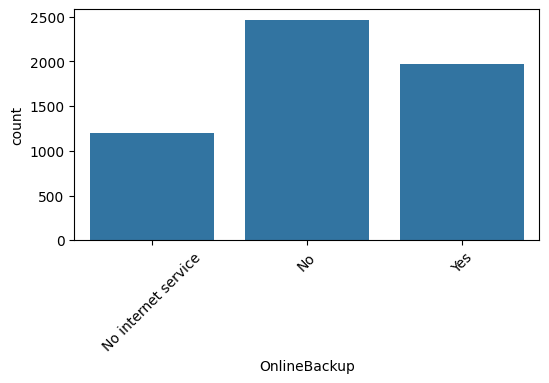

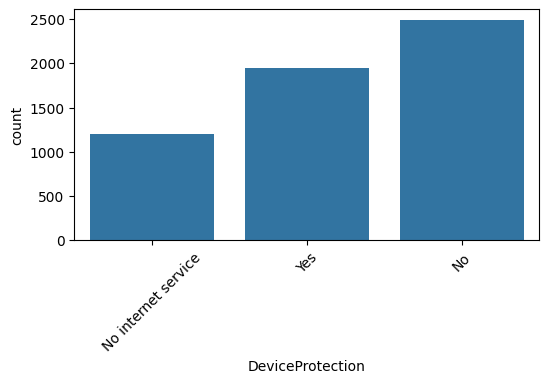

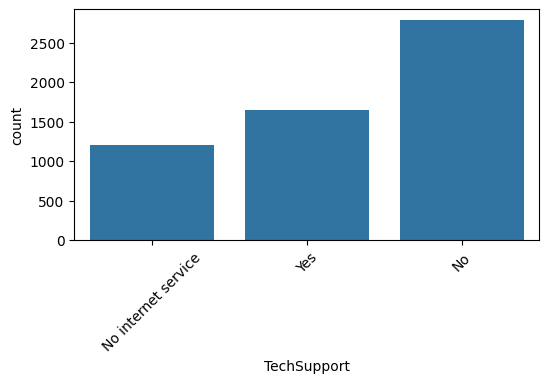

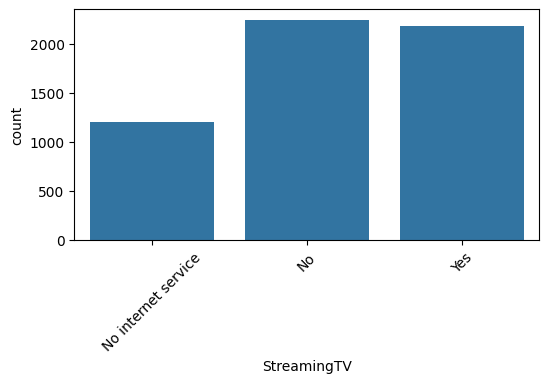

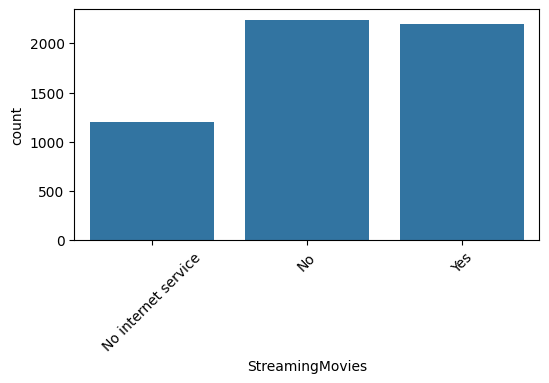

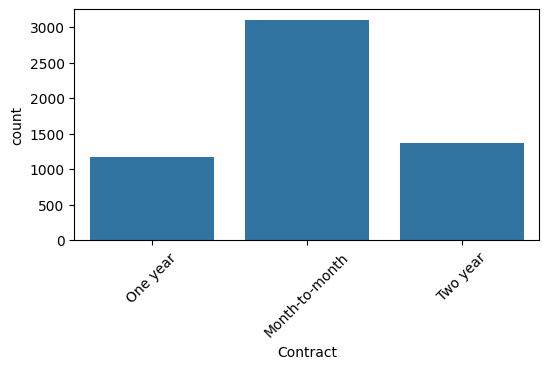

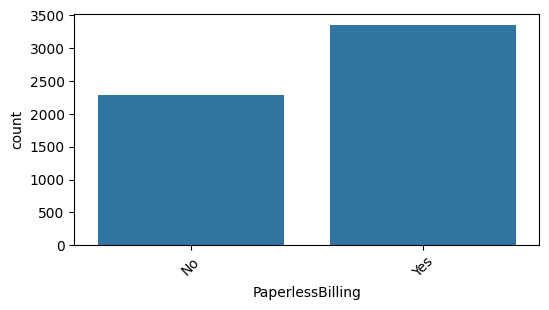

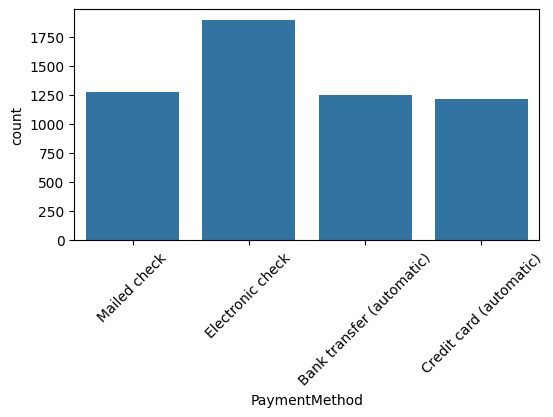

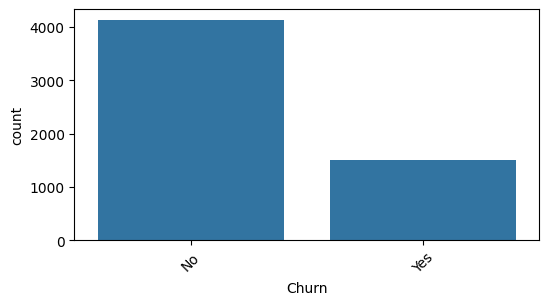

In [213]:
cat_cols=train.select_dtypes(include='object').columns
cat_cols
for col in cat_cols:
    plt.figure(figsize=(6,3))
    sns.countplot(data=train,x=col)
    plt.xticks(rotation=45)
    plt.show()

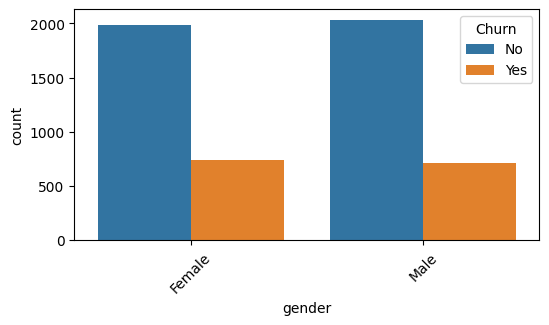

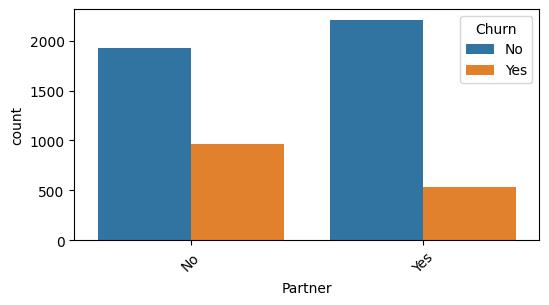

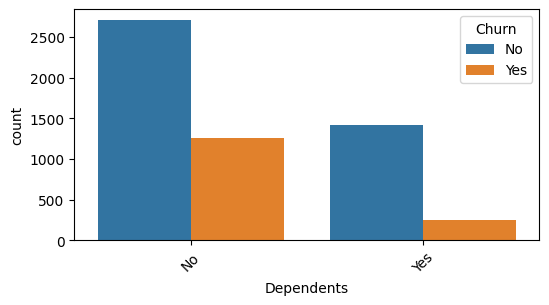

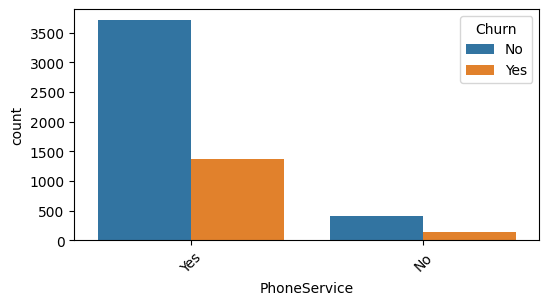

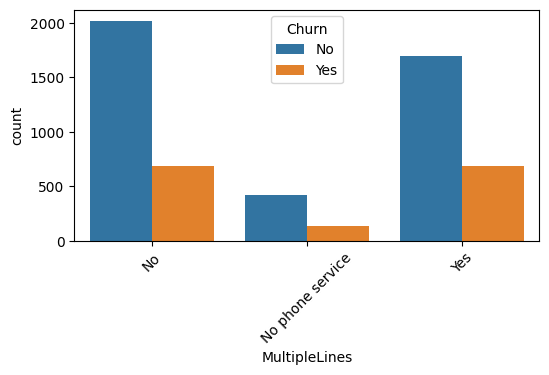

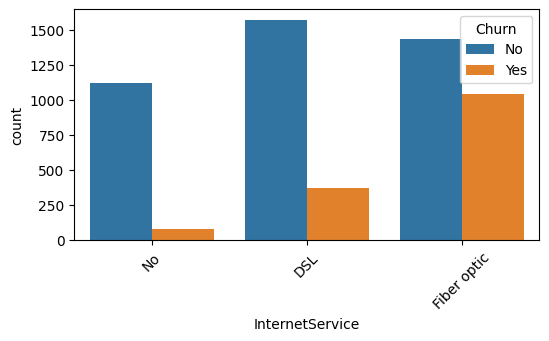

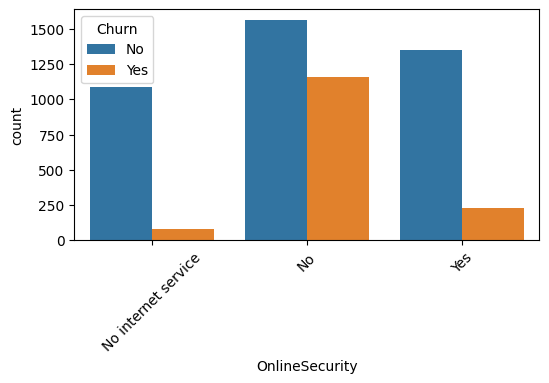

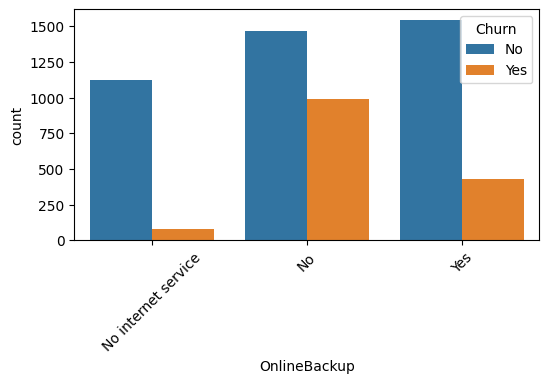

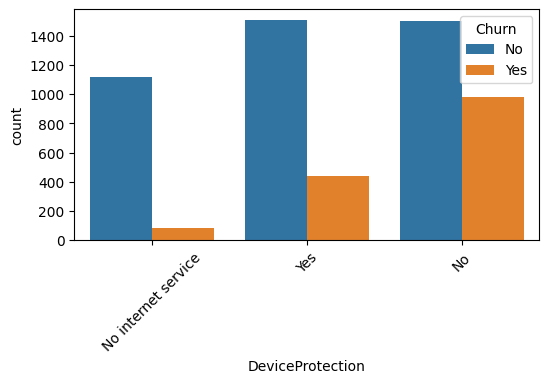

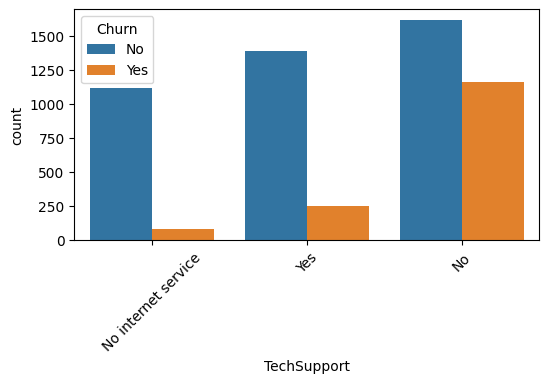

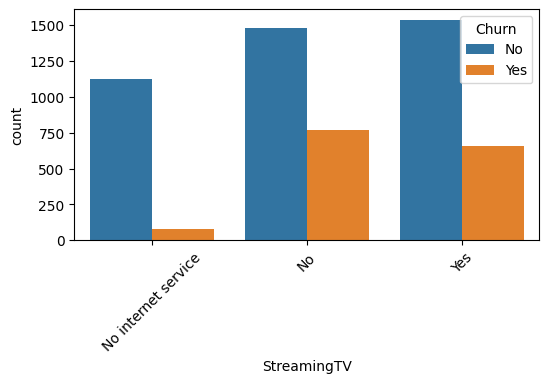

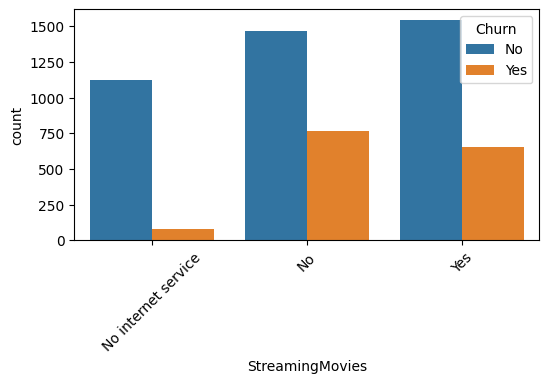

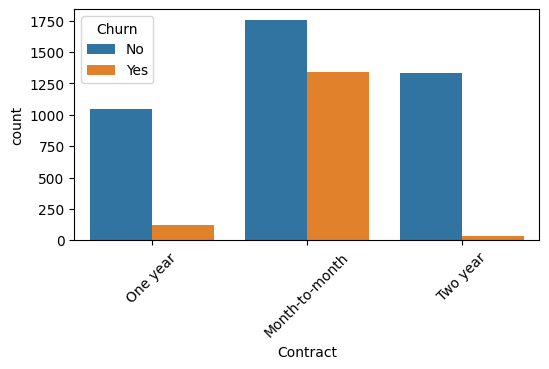

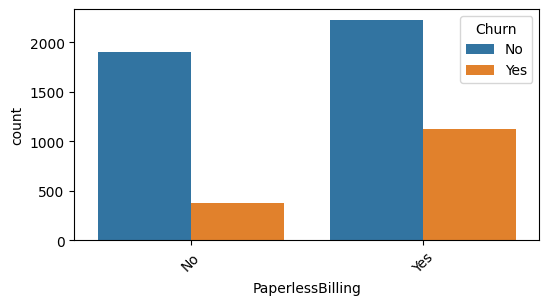

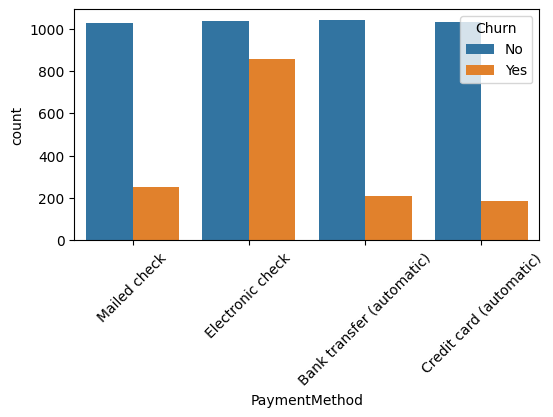

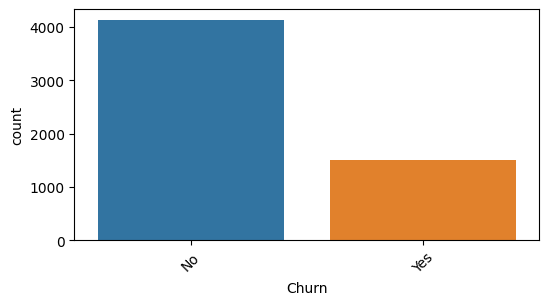

In [214]:
# Relationship with Churn
for col in cat_cols:
    plt.figure(figsize=(6,3))
    sns.countplot(data=train,x=col,hue='Churn')
    plt.xticks(rotation=45)
    plt.show()

In [215]:
# Feature Engineering
# Customer Lifetime Value
train['CustomerLifetimeValue']=train['tenure']*train['MonthlyCharges']

In [216]:
train['Tenure_Contract']=train['Contract']+"_"+train['tenure'].astype(str)

In [217]:
encoder=LabelEncoder()

for col in train.columns:
    if train[col].dtype=='object':
        train[col]=encoder.fit_transform(train[col])

In [218]:
# Feature Selection
X=train.drop("Churn",axis=1)
y=train["Churn"]

In [219]:
X_train,X_valid,y_train,y_valid=train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [220]:
# feature scaling

scaler=StandardScaler()
X_train=scaler.fit_transform(X_train)
X_valid=scaler.transform(X_valid)

In [221]:
train.isnull().sum()

,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0
OnlineBackup,0


In [222]:
train['MonthlyCharges'].isnull().sum()

np.int64(394)

In [223]:
# Fill the missing values
# Since MonthlyCharges is a numerical column, fill it with the median:
from sklearn.impute import SimpleImputer
monthly_imputer = SimpleImputer(strategy='median')
train[['MonthlyCharges']] = monthly_imputer.fit_transform(train[['MonthlyCharges']])

In [224]:
# Recreate CustomerLifetimeValue
# Because it was created before imputing MonthlyCharges, recreate it:

train['CustomerLifetimeValue'] = train['tenure'] * train['MonthlyCharges']

In [225]:
train.isnull().sum()

,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0
OnlineBackup,0


In [226]:
X = train.drop("Churn", axis=1)
y = train["Churn"]

In [227]:
X_train, X_valid, y_train, y_valid = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [228]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_valid = scaler.transform(X_valid)

In [229]:
# Model 1 : Logistic Regression
lr=LogisticRegression(max_iter=1000)

lr.fit(X_train,y_train)

pred1=lr.predict(X_valid)

In [230]:
print("Accuracy:",accuracy_score(y_valid,pred1))

print("Precision:",precision_score(y_valid,pred1))

print("Recall:",recall_score(y_valid,pred1))

print("F1:",f1_score(y_valid,pred1))

print(classification_report(y_valid,pred1))

Accuracy: 0.805678793256433
Precision: 0.6529850746268657
Recall: 0.5813953488372093
F1: 0.6151142355008787
              precision    recall  f1-score   support

           0       0.85      0.89      0.87       826
           1       0.65      0.58      0.62       301

    accuracy                           0.81      1127
   macro avg       0.75      0.73      0.74      1127
weighted avg       0.80      0.81      0.80      1127



In [231]:
# Model 2 : Random Forest
rf=RandomForestClassifier(random_state=42)
rf.fit(X_train,y_train)
pred2=rf.predict(X_valid)

print("Accuracy:",accuracy_score(y_valid,pred2))
print("Precision:",precision_score(y_valid,pred2))
print("Recall:",recall_score(y_valid,pred2))
print("F1:",f1_score(y_valid,pred2))

Accuracy: 0.7976929902395741
Precision: 0.6489795918367347
Recall: 0.5282392026578073
F1: 0.5824175824175825


In [232]:
# Model 3 : Gradient Boosting

gb=GradientBoostingClassifier(random_state=42)
gb.fit(X_train,y_train)
pred3=gb.predict(X_valid)

print("Accuracy:",accuracy_score(y_valid,pred3))
print("Precision:",precision_score(y_valid,pred3))
print("Recall:",recall_score(y_valid,pred3))
print("F1:",f1_score(y_valid,pred3))

Accuracy: 0.8074534161490683
Precision: 0.668
Recall: 0.5548172757475083
F1: 0.6061705989110708


In [233]:
# Model Comparison

comparison=pd.DataFrame({

'Model':['Logistic Regression','Random Forest','Gradient Boosting'],

'Accuracy':[accuracy_score(y_valid,pred1),
accuracy_score(y_valid,pred2),
accuracy_score(y_valid,pred3)],

'Precision':[precision_score(y_valid,pred1),
precision_score(y_valid,pred2),
precision_score(y_valid,pred3)],

'Recall':[recall_score(y_valid,pred1),
recall_score(y_valid,pred2),
recall_score(y_valid,pred3)],

'F1 Score':[f1_score(y_valid,pred1),
f1_score(y_valid,pred2),
f1_score(y_valid,pred3)]

})

comparison

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.805679,0.652985,0.581395,0.615114
1,Random Forest,0.797693,0.648980,0.528239,0.582418
2,Gradient Boosting,0.807453,0.668000,0.554817,0.606171


Hyperparameter Tuning (Random Forest)

In [234]:
params={

'n_estimators':[100,200],

'max_depth':[5,10,None],

'min_samples_split':[2,5],

'min_samples_leaf':[1,2]

}

In [235]:
grid=GridSearchCV(

RandomForestClassifier(random_state=42),

params,

cv=5,

scoring='f1',

n_jobs=-1

)

grid.fit(X_train,y_train)

GridSearchCV(cv=5, estimator=RandomForestClassifier(random_state=42), n_jobs=-1,
             param_grid={'max_depth': [5, 10, None], 'min_samples_leaf': [1, 2],
                         'min_samples_split': [2, 5],
                         'n_estimators': [100, 200]},
             scoring='f1')

In [236]:
grid.best_params_

{'max_depth': 10,
 'min_samples_leaf': 2,
 'min_samples_split': 5,
 'n_estimators': 200}

In [237]:
best_model=grid.best_estimator_

pred_best=best_model.predict(X_valid)

In [238]:
print("Accuracy:",accuracy_score(y_valid,pred_best))

print("Precision:",precision_score(y_valid,pred_best))

print("Recall:",recall_score(y_valid,pred_best))

print("F1:",f1_score(y_valid,pred_best))

Accuracy: 0.805678793256433
Precision: 0.664
Recall: 0.5514950166112956
F1: 0.6025408348457351


Load Testing Dataset

In [239]:
test=pd.read_csv("Testing_data.csv")
test.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,6080-TCMYC,Male,0,Yes,Yes,40,Yes,Yes,Fiber optic,No,...,Yes,No,No,No,Month-to-month,Yes,Electronic check,81.20,3292.3,No
1,7285-KLOTR,Female,0,Yes,No,12,Yes,Yes,DSL,Yes,...,Yes,No,Yes,Yes,One year,No,Electronic check,78.85,876.75,No
2,7486-KSRVI,Male,0,No,No,43,Yes,Yes,Fiber optic,No,...,No,Yes,Yes,Yes,One year,Yes,Electronic check,100.00,4211.55,Yes
3,9924-JPRMC,Male,0,No,No,72,Yes,Yes,Fiber optic,Yes,...,Yes,Yes,Yes,Yes,Two year,Yes,Electronic check,118.20,8547.15,No
4,4439-YRNVD,Female,0,No,No,10,No,No phone service,DSL,No,...,No,Yes,No,No,Month-to-month,No,Electronic check,36.25,374,No


Apply same PreProcessing

In [240]:
ids=test['customerID']
test=test.drop('customerID',axis=1)

test['TotalCharges']=test['TotalCharges'].replace(" ",np.nan)
test['TotalCharges']=test['TotalCharges'].astype(float)
test['TotalCharges']=imputer.transform(test[['TotalCharges']])
test['CustomerLifetimeValue']=test['tenure']*test['MonthlyCharges']
test['Tenure_Contract']=test['Contract']+"_"+test['tenure'].astype(str)

Encode using the same approach

In [241]:
for col in test.columns:
    if test[col].dtype=='object':
        test[col]=LabelEncoder().fit_transform(test[col])

Scaling

In [243]:

test.columns

Index(['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure',
       'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity',
       'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV',
       'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod',
       'MonthlyCharges', 'TotalCharges', 'Churn', 'CustomerLifetimeValue',
       'Tenure_Contract'],
      dtype='object')

In [245]:
test.head()


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,...,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,CustomerLifetimeValue,Tenure_Contract
0,1,0,1,1,40,1,2,1,0,0,...,0,0,0,1,2,81.20,3292.30,0,3248.0,34
1,0,0,1,0,12,1,2,0,2,0,...,2,2,1,0,2,78.85,876.75,0,946.2,71
2,1,0,0,0,43,1,2,1,0,0,...,2,2,1,1,2,100.00,4211.55,1,4300.0,105
3,1,0,0,0,72,1,2,1,2,2,...,2,2,2,1,2,118.20,8547.15,0,8510.4,198
4,0,0,0,0,10,0,1,0,0,2,...,0,0,0,0,2,36.25,374.00,0,362.5,1


In [246]:
test = test.drop("Churn", axis=1)

In [247]:
# Check that the training and test features match

print(X.columns.tolist())
print(test.columns.tolist())

['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'CustomerLifetimeValue', 'Tenure_Contract']
['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'CustomerLifetimeValue', 'Tenure_Contract']


In [248]:
test_scaled = scaler.transform(test)

In [249]:
predictions = best_model.predict(test_scaled)

In [250]:
encoders = {}

for col in train.columns:
    if train[col].dtype == 'object':
        le = LabelEncoder()
        train[col] = le.fit_transform(train[col])
        encoders[col] = le

In [251]:
# then here testing the data
for col in test.columns:
    if col in encoders:
        test[col] = encoders[col].transform(test[col])

In [252]:
predictions=np.where(predictions==1,'Yes','No')

In [253]:
submission=pd.DataFrame({

'customerID':ids,

'Churn':predictions

})

submission.to_csv("Customer_Churn_Predictions.csv",index=False)

submission.head()

,customerID,Churn
0,6080-TCMYC,No
1,7285-KLOTR,No
2,7486-KSRVI,No
3,9924-JPRMC,No
4,4439-YRNVD,No


In [258]:
test.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,...,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,CustomerLifetimeValue,Tenure_Contract
0,1,0,1,1,40,1,2,1,0,0,...,0,0,0,0,1,2,81.20,3292.30,3248.0,34
1,0,0,1,0,12,1,2,0,2,0,...,0,2,2,1,0,2,78.85,876.75,946.2,71
2,1,0,0,0,43,1,2,1,0,0,...,2,2,2,1,1,2,100.00,4211.55,4300.0,105
3,1,0,0,0,72,1,2,1,2,2,...,2,2,2,2,1,2,118.20,8547.15,8510.4,198
4,0,0,0,0,10,0,1,0,0,2,...,2,0,0,0,0,2,36.25,374.00,362.5,1


In [255]:
submission.sample(10)

,customerID,Churn
702,2604-IJPDU,No
724,6457-USBER,Yes
1277,1370-GGAWX,No
919,8782-NUUOL,No
224,9715-WZCLW,No
780,8659-HDIYE,No
506,1496-GGSUK,Yes
67,5701-GUXDC,No
241,8430-TWCBX,No
1129,9172-JITSM,Yes


In [256]:
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': best_model.feature_importances_
})

feature_importance = feature_importance.sort_values(by='Importance', ascending=False)

feature_importance.head(10)

,Feature,Importance
20,Tenure_Contract,0.154073
17,MonthlyCharges,0.109768
4,tenure,0.107430
14,Contract,0.101963
19,CustomerLifetimeValue,0.098833
18,TotalCharges,0.093602
8,OnlineSecurity,0.062924
11,TechSupport,0.047020
7,InternetService,0.041250
16,PaymentMethod,0.033844


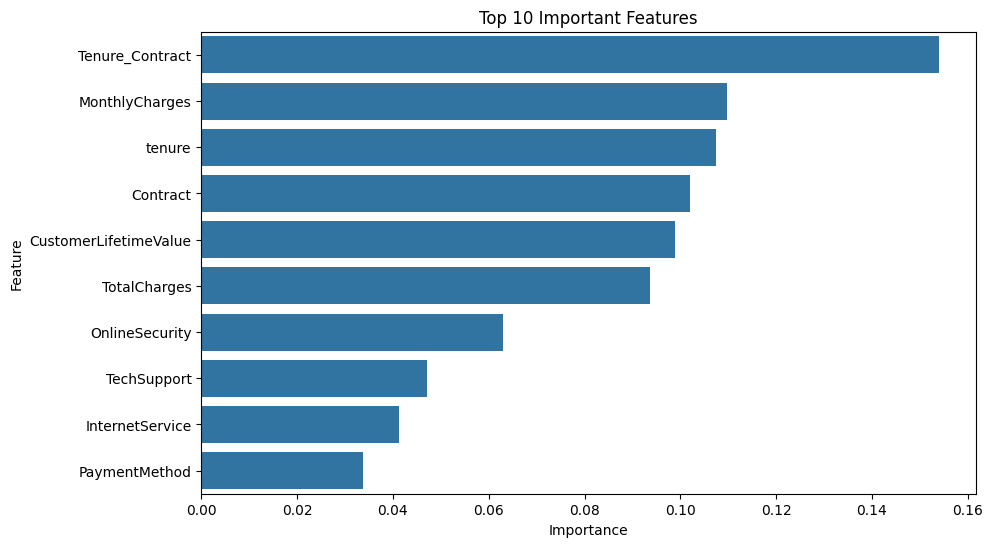

In [257]:
plt.figure(figsize=(10,6))
sns.barplot(data=feature_importance.head(10),
            x='Importance',
            y='Feature')
plt.title("Top 10 Important Features")
plt.show()